# Synthetic Data

In [1]:
import os 
import numpy as np
from package import *
save_path = os.getcwd() + '\\' + 'image' + '\\' + 'simulation'+ '\\'
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'

### An example to generate comparison graph 

$n$ is the number of items. <br>
$N$ is the number of comparison/hyperedge. (we allow the multi-edge.) <br>
$v$ is the covariates' coeffecient.<br>
$[m_{lower}, m_{upper})$ is the interval of all possible edge size.

In [83]:
n = 400
N = lambda n: int(n*(n-1)/2)
v = [1,-0.5,0]
d = len(v)
m_lower = 2
m_upper = 3

H.T, H.X are two lists containing corresponding item index and covariates.

In [84]:
H = generator.MultipleComparison(n,N,v,m_lower=m_lower,m_upper=m_upper)
print(f'Number of items:{H.n}')
print(f'Number of comparisons:{H.N}')
#print(f'Comparisons:{H.T}')
#print(f'Covariates:{H.X}')


complete get edges: Num_Edges=79800, Num_Nodes = 400,m_lower = 2,m_upper = 2
Number of items:400
Number of comparisons:79800


##### Estimation

Set ''detail = True'' to see the details of alternating method. <br>
Using  ''type='pair' '' can significantly improve the velocity of pairwise case.

In [4]:
detail = True
u_estimation, v_estimation = algorithm.AM(H.T,H.X,n,detail=detail,type = 'pair')

-----1-----
log-likelihood: -0.6931471805588296
v iterative times: 7 and v = [ 0.98395494 -0.4939881   0.01221319]
u iterative times: 21
-----2-----
log-likelihood: -0.5034554039376773
v iterative times: 5 and v = [ 1.02172521 -0.51399931  0.01173552]
u iterative times: 10
u iterative times: 2


In [ ]:
detail = True
u_estimation, v_estimation = algorithm.AM(H.T,H.X,n,d,detail=detail,type = 'multi')

-----1-----
log-likelihood: -0.6931471805588296
v iterative times: 6 and v = [ 0.96352078 -0.48720692  0.00762969]
u iterative times: 21
-----2-----
log-likelihood: -0.5066295092267757
v iterative times: 4 and v = [ 0.99896165 -0.5052607   0.0099707 ]
u iterative times: 10


##### Error bound

In [ ]:
u_true, v_true = H.u,H.v
u_infty = max(abs(u_estimation-u_true))
v_infty = max(abs(v_estimation-v_true))

print(f'u_infty:{u_infty}')
print(f'v_infty:{v_infty}')

u_infty:0.4647840363322926
v_infty:0.01002895996317777


### Convergence rate

In [4]:
U = [np.zeros(n)]
V = [np.zeros(d)]
UU,VV = [],[]
for i in range(3):
    U = MM_pair(H.T,H.X,V[-1],n,utr=U[-1])
    V = Newton_pair(H.T,H.X,U[-1],d,vtr=V[-1],E=1e-12)
    U_error = [np.linalg.norm(u-U[-1]) for u in U[:-1]]
    U_error_ratio = [U_error[i+1]/U_error[i] for i in range(len(U_error)-1)]
    V_error = [np.linalg.norm(v-V[-1]) for v in V[:-1]]
    V_error_ratio = [V_error[i+1]/V_error[i] for i in range(len(V_error)-1)]
    #UU.append(U_error_ratio)
    #VV.append(V_error_ratio)
    UU.append(U_error)
    VV.append(V_error)


C:\Users\13299\AppData\Local\Temp\ipykernel_15012\461152776.py:32: RuntimeWarning: invalid value encountered in log
  ax.plot(range(len(V)),np.log(-np.log(V)),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)


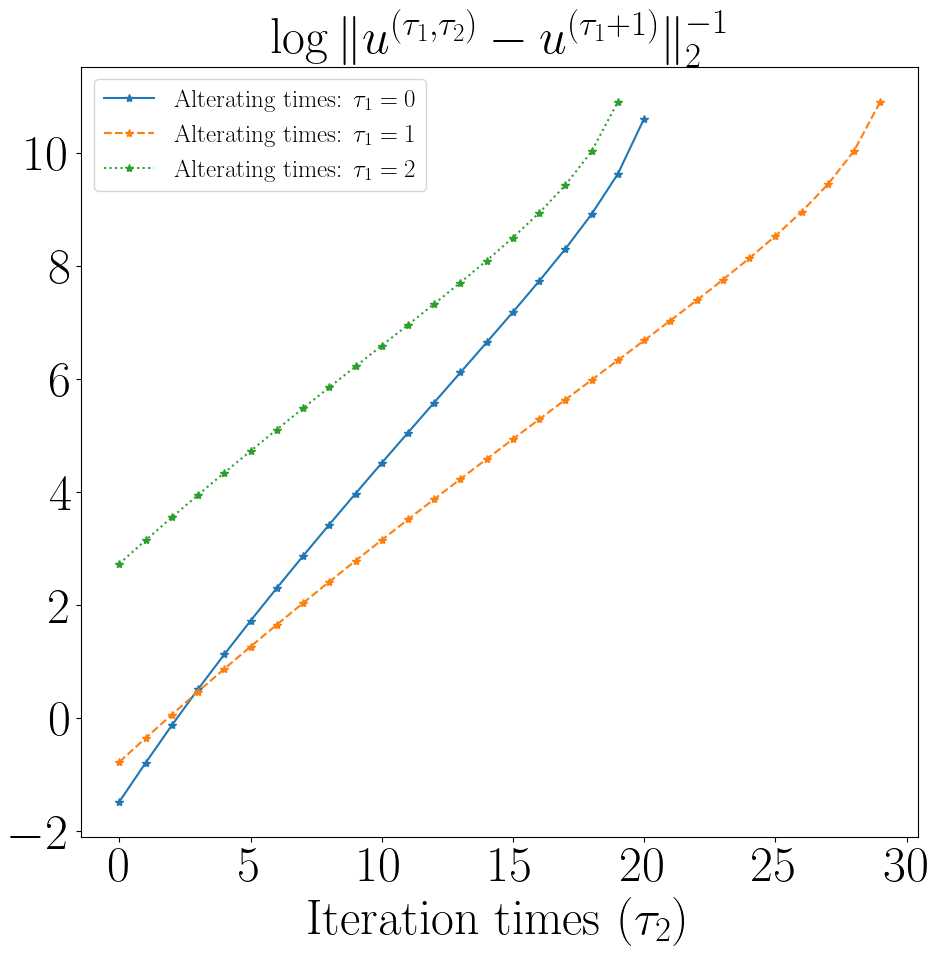

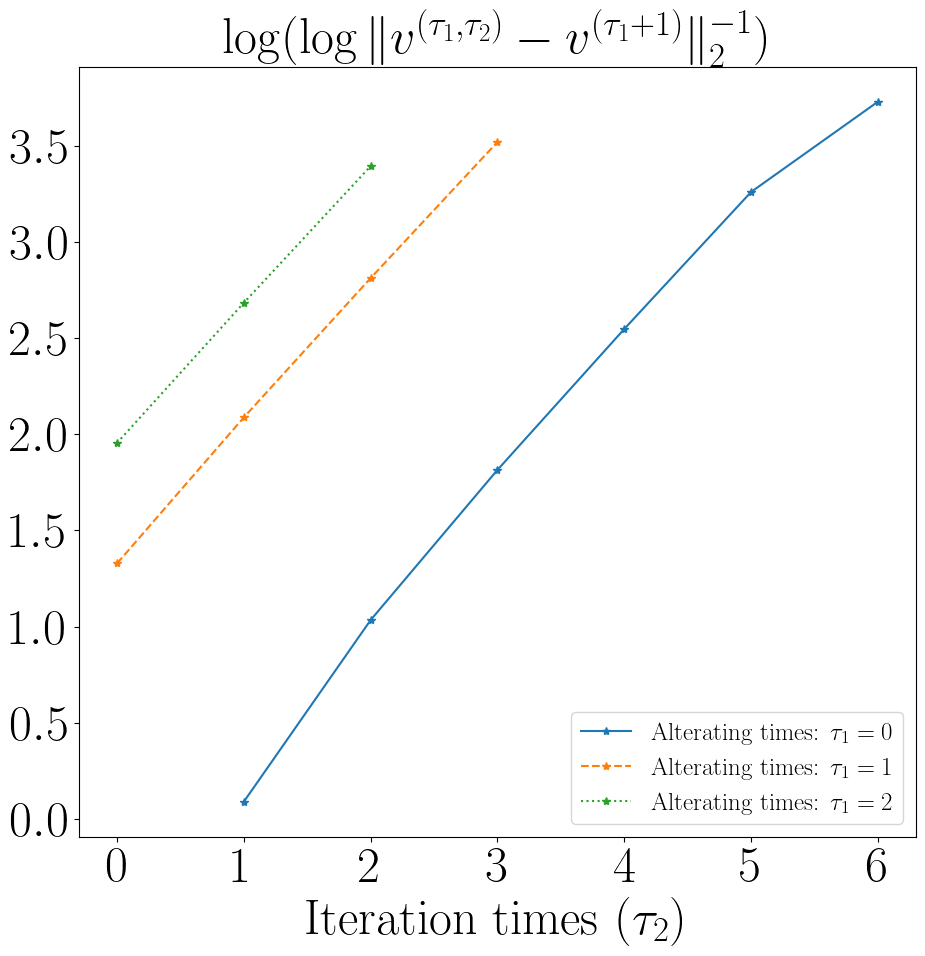

In [22]:
import matplotlib.pyplot as plt

T = ['-*','--*',':*',':']
rc('text', usetex=True)
rc('font', family='serif')
sz = 36

title = ""
#Tu_ = r'$\frac{\|u^{(\tau_1,\tau_2+1)}-u^{(\tau_1+1)}\|_2}{\|u^{(\tau_1,\tau_2)}-u^{(\tau_1+1)}\|_2}$'
Tu_ = r'$\log\|u^{(\tau_1,\tau_2)}-u^{(\tau_1+1)}\|^{-1}_2$'
#Tv_ = r'$\frac{\|v^{(\tau_1,\tau_2+1)}-v^{(\tau_1+1)}\|_2}{\|v^{(\tau_1,\tau_2)}-v^{(\tau_1+1)}\|_2}$'
Tv_ = r'$\log(\log\|v^{(\tau_1,\tau_2)}-v^{(\tau_1+1)}\|^{-1}_2)$'
ylabel = 'Error ratio'
xlabel = r'Iteration times ($\tau_2$)'

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.title(title+Tu_,size =sz)
for i,U in enumerate(UU):
    ax.plot(range(len(U)),-np.log(U),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    #ax.plot(np.log(U[:-1]),np.log(U[1:])-np.log(U[:-1]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_u.pdf')

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.title(title+Tv_,size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
for i,V in enumerate(VV):
    ax.plot(range(len(V)),np.log(-np.log(V)),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    #ax.plot(np.log(V[:-1]),np.log(V[1:])-np.log(V[:-1]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_v.pdf')


plt.show()

### Does covariate fully capture the score?（simulation）

In [ ]:
file_name = 'inference test'
file_name_1 = 'DS'
file_name_2 = 'Dp-v'
rc('text', usetex=True)
rc('font', family='serif')
sz = 36
n = 100
N = lambda n: int(n*(n-1)/2)
u_generator = lambda n: np.array([0 for _ in range(n)])
v = [1,-0.5,0]
d = len(v)

In [ ]:
from joblib import Parallel, delayed
num = 20
def test(n,N,v,d,u_generator=u_generator,num=20):
    H = generator.MultipleComparison(n,N,v,u_generator=u_generator)
    chi2,dof = algorithm.test_statistic(H.T,H.X,n,d,num=num)
    return chi2
res = Parallel(n_jobs=5)(delayed(test)(n,N,v,d,u_generator,num) for _ in range(1000))
with open(save_data_path+file_name+'.txt','a') as file:
    for r in res:
        file.write(str(r)+'\n')

In [3]:
Data = []
with open(save_data_path+file_name+'.txt','r') as file:
    for line in file:
        Data.append(float(line))

Distribution of statistic

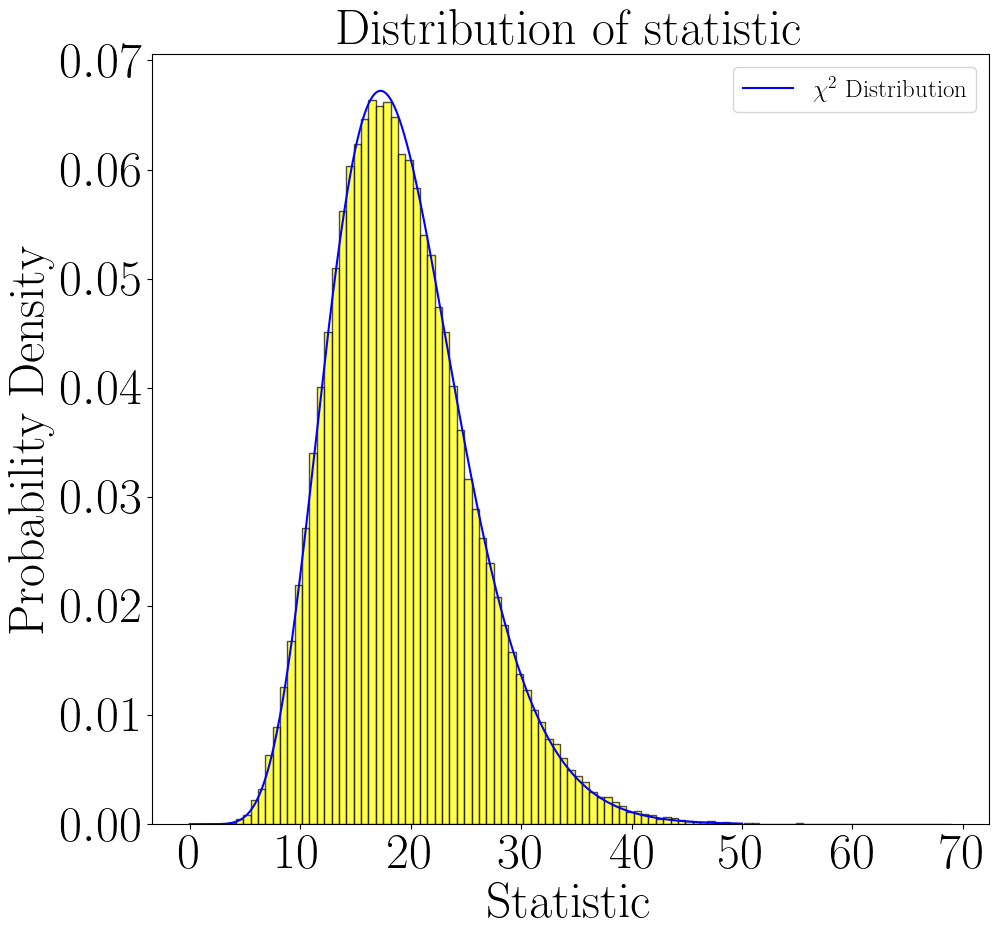

In [37]:

plt.figure(figsize=(10.8, 10))
x = np.linspace(0, 50, 1000)
pdf = chi2.pdf(x, np.mean(Data))
plt.hist(Data, bins=100, alpha=0.7, color='yellow', edgecolor='black',density = True)
plt.plot(x, pdf, label=r'$\chi^2$ Distribution', color='blue')
plt.title("Distribution of statistic",size =sz)
plt.xlabel('Statistic',size =sz)
plt.ylabel('Probability Density',size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+file_name_1+'.pdf')


Distribution of $p$ value

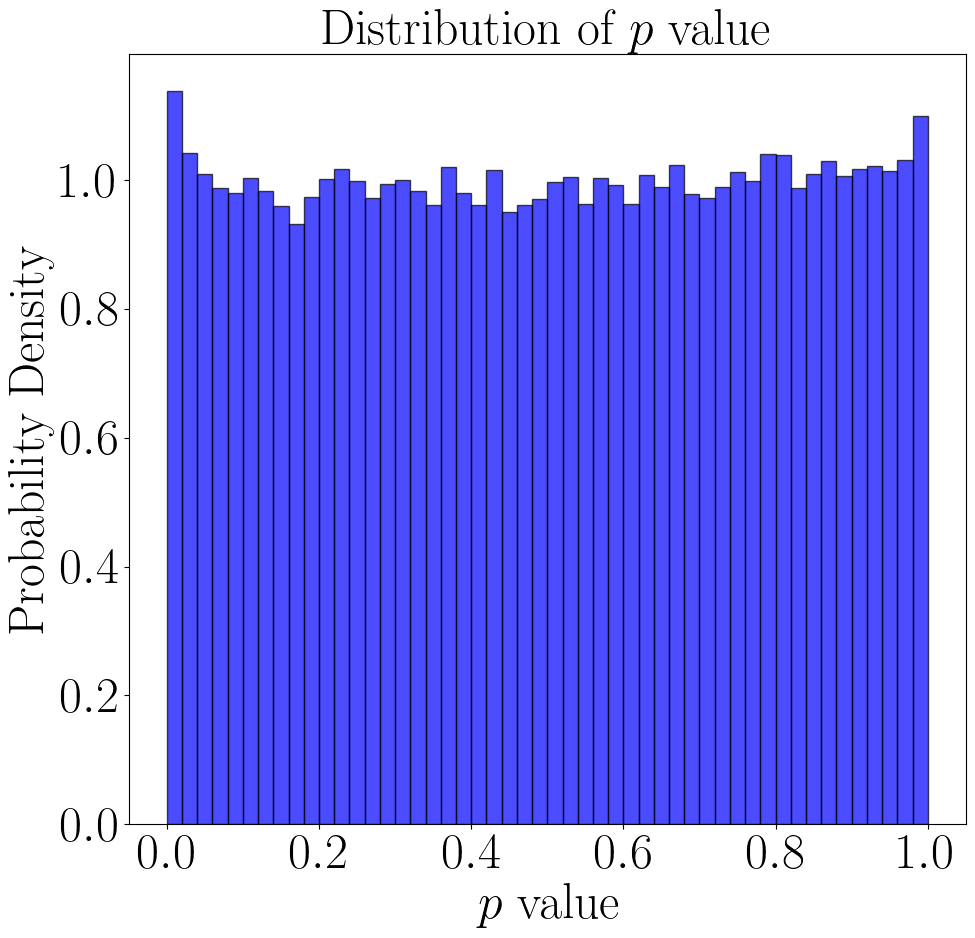

In [38]:
p_value = 1-chi2.cdf(Data,np.mean(Data))
plt.figure(figsize=(10.8, 10))
#x = np.linspace(0, 50, 1000)
#pdf = chi2.cdf(x, np.mean(res))
plt.hist(p_value, bins=50, alpha=0.7, color='blue', edgecolor='black',density = True)
#plt.plot(x, pdf, label=f'Chi-squared Distribution', color='blue')
plt.title(r'Distribution of $p$ value',size=sz)
plt.xlabel(r'$p$ value',size=sz)
plt.ylabel('Probability Density',size=sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.savefig(save_path+file_name_2+'.pdf')
